<a href="https://colab.research.google.com/github/Mingshi-Yao/Mingshi-Yao.github.io/blob/main/case1_cost_of_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case1 cost of quality — vision inspection on the line

Scaffold for Case 1: cost-of-quality baseline, three alternatives, PW/AW, incremental analysis, sensitivity.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ri128-rutgers/quality-management-fall2026/blob/main/case1_cost_of_quality.ipynb) · Also opens in Azure ML Studio notebooks or any Jupyter; nothing here needs a GPU.

**How to use:** run every cell top to bottom once. Cells marked `# >>> YOUR WORK` are where you change inputs or add interpretation. Keep your AI-assistant transcript if you used one; the verification log asks what you checked.

In [1]:
# Setup — works in Colab and locally
import os, sys, io, urllib.request
REPO = 'ri128-rutgers/quality-management-fall2026'
DATA_BASE = f'https://raw.githubusercontent.com/{REPO}/main/' if 'google.colab' in sys.modules or not os.path.exists('../data') else '../data/'
if 'google.colab' in sys.modules:
    urllib.request.urlretrieve(f'https://raw.githubusercontent.com/{REPO}/main/tvm.py', 'tvm.py')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tvm import *
pd.options.display.float_format = '{:,.2f}'.format
def load(name): return pd.read_csv(DATA_BASE + name)
print('data from', DATA_BASE)

data from https://raw.githubusercontent.com/ri128-rutgers/quality-management-fall2026/main/


In [7]:
A = load('case1_data_assumptions.csv').set_index('parameter')['value']
hist = load('case1_line_history.csv')
print(hist.tail(3)); print(A.head(12))
print(load("case1_data_assumptions.csv").to_string(index=False))

      month  units_shipped  escape_ppm  rework_rate  customer_complaints
21  2026-06         372599        1075         0.02                    9
22  2026-07         327936         965         0.01                    6
23  2026-08         354157        1214         0.01                    6
parameter
annual_units_shipped                   4200000
volume_growth_per_year                    0.03
inspectors_per_shift_current                 4
shifts                                       3
inspector_fully_loaded_hourly_usd         34.5
hours_per_inspector_year                  1950
escape_rate_ppm_current                   1100
chargeback_per_escaped_unit_usd           38.0
customer_audit_cost_per_quarter_usd       9500
internal_rework_rate                     0.018
rework_cost_per_unit_usd                   6.2
MARR                                      0.12
Name: value, dtype: object
                          parameter      value                                                             

In [3]:
# Baseline: current annual cost of quality, sorted into P-A-F buckets
units = float(A['annual_units_shipped']); rate = float(A['inspector_fully_loaded_hourly_usd']); hrs = float(A['hours_per_inspector_year'])
appraisal = int(A['inspectors_per_shift_current']) * int(A['shifts']) * rate * hrs
internal_failure = units * float(A['internal_rework_rate']) * float(A['rework_cost_per_unit_usd'])
external_failure = units * float(A['escape_rate_ppm_current'])/1e6 * float(A['chargeback_per_escaped_unit_usd']) + 4*float(A['customer_audit_cost_per_quarter_usd'])
prevention = 0.0   # >>> YOUR WORK: is anything in the current state prevention spend?
# An inspector’s wages could be partly prevention spending if that person also performs documented preventive work—for example, developing assembly procedures.
## But as the BASELINE, it's better we record the prevention spend as 0 on current state for further analysis.
coq = pd.Series({'prevention': prevention, 'appraisal': appraisal, 'internal failure': internal_failure, 'external failure': external_failure})
print(coq.round(0)); print('total', round(coq.sum()))

prevention               0.00
appraisal          807,300.00
internal failure   468,720.00
external failure   213,560.00
dtype: float64
total 1489580


In [4]:
# Alternatives: build 5-year cash-flow lists (year 0..5), negative = cost. Ranges: pick a value and record why.
MARR = float(A['MARR']); N = 5; g = float(A['volume_growth_per_year']); infl = float(A['general_inflation'])
# >>> YOUR WORK: choose values inside the stated ranges
# I set C_renewal_uplift as 10 since the average interest is about 3% and it's about to conpounded to 10% for 3 years.
# C_escape_ppm is 300 which is a bit larger, since I assume the on-site engineeror is better somehow.
# Other values I keep the same.
B_families_per_year = 4; B_escape_ppm = 250; C_escape_ppm = 300; C_renewal_uplift = 0.10
def year_costs(inspectors_per_shift, escape_ppm, extra_fixed=0.0, yr=1):
    u = units * (1+g)**(yr-1)
    lab = inspectors_per_shift * int(A['shifts']) * rate * hrs * (1+infl)**(yr-1)
    ext = u * escape_ppm/1e6 * float(A['chargeback_per_escaped_unit_usd']) + 4*float(A['customer_audit_cost_per_quarter_usd'])
    rw = u * float(A['internal_rework_rate']) * float(A['rework_cost_per_unit_usd'])
    return lab + ext + rw + extra_fixed
cf_A = [0] + [-year_costs(int(A['inspectors_per_shift_current'])+int(A['alt_A_added_inspectors_per_shift']), float(A['alt_A_escape_ppm_after']), yr=y) for y in range(1, N+1)]
cf_B = [-float(A['alt_B_capex_usd'])] + [-(year_costs(int(A['alt_B_inspectors_per_shift_after']), B_escape_ppm, float(A['alt_B_support_per_year_usd']) + B_families_per_year*float(A['alt_B_retrain_cost_per_event_usd']), yr=y)) for y in range(1, N+1)]
cf_B[-1] += float(A['alt_B_salvage_year5_usd'])
sub = float(A['alt_C_fee_per_line_month_usd'])*int(A['alt_C_lines'])*12
cf_C = [-float(A['alt_C_onboarding_fee_usd'])] + [-(year_costs(int(A['alt_C_inspectors_per_shift_after']), C_escape_ppm, sub*(1 if y<=3 else 1+C_renewal_uplift), yr=y)) for y in range(1, N+1)]
for k, cf in {'A': cf_A, 'B': cf_B, 'C': cf_C}.items():
    print(k, 'PW', round(pw(cf, MARR)), 'AW', round(aw(cf, MARR)))

A PW -6195368 AW -1718655
B PW -3578302 AW -992656
C PW -3575278 AW -991817


In [5]:
# Incremental analysis B vs C (both 5-year streams here; state the unequal-life assumption you used for C's 3-year term)
inc = np.array(cf_B) - np.array(cf_C)
print('increment B-C:', inc.round(0)); print('incremental IRR:', incremental_irr(cf_C, cf_B))
# >>> YOUR WORK: interpret. If the increment has no sign change, say so and use PW.

increment B-C: [-385000.   96792.   96888.   96986.  112256.  137361.]
incremental IRR: 0.11700261757039693


families/yr        3        4        5
escape_ppm                            
180         -3504950 -3550010 -3595069
250         -3547428 -3592488 -3637547
320         -3589906 -3634966 -3680026


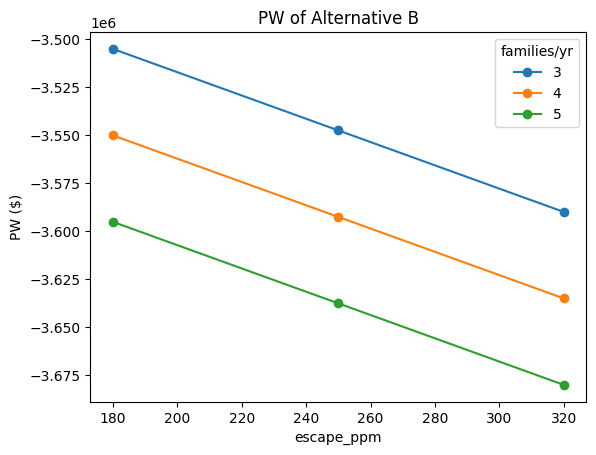

In [6]:
# Sensitivity: escape rate after deployment and retraining events per year
rows = []
for ppm in [180, 250, 320]:
    for fam in [3, 4, 5]:
        cfb = [-float(A['alt_B_capex_usd'])] + [-(year_costs(1, ppm, float(A['alt_B_support_per_year_usd']) + fam*float(A['alt_B_retrain_cost_per_event_usd']), yr=y)) for y in range(1, N+1)]
        rows.append({'escape_ppm': ppm, 'families/yr': fam, 'PW_B': round(pw(cfb, MARR))})
sens = pd.DataFrame(rows).pivot(index='escape_ppm', columns='families/yr', values='PW_B'); print(sens)
sens.plot(marker='o'); plt.title('PW of Alternative B'); plt.ylabel('PW ($)'); plt.show()

**Now write the memo.** Four pages max: answer first, cost of quality table, cash-flow diagrams (draw them by hand or in any tool), the comparison, the sensitivity, the recommendation, the AI-use note.